## Import Libraries

In [2]:
# Import the necessary libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Import Dataset

In [4]:
file_path = "Dataset"
files = os.listdir(file_path)
dataset = 'NBA_stat.csv'
df = pd.read_csv(os.path.join(file_path,dataset))
df.head()

,Unnamed: 0,Player,Rk,Age,Team,Pos,G,GS,MP,FG,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0,Amen Thompson,1,23,HOU,PG,79,79,2953,9.4,...,13.5,20.0,6.5,3.8,10.3,0.167,1.6,1.0,2.6,3.4
1,1,Kevin Durant,2,37,HOU,SF,78,78,2840,12.6,...,13.5,27.1,7.5,3.2,10.7,0.180,4.4,0.1,4.5,4.7
2,2,Desmond Bane,3,27,ORL,SG,82,82,2756,10.2,...,10.8,23.3,4.8,2.6,7.4,0.129,1.6,-0.2,1.4,2.3
3,3,Toumani Camara,4,25,POR,PF,82,82,2731,6.9,...,13.1,16.3,2.1,2.7,4.8,0.084,-1.0,0.0,-1.0,0.7
4,4,Jabari Smith Jr.,5,22,HOU,PF,77,77,2705,8.1,...,9.0,18.2,3.4,3.3,6.6,0.118,-0.5,-0.2,-0.7,0.9


## Data Checking

In [6]:
# Drop the unnecessary columns and set index to Player
df.drop(['Unnamed: 0', 'Rk'], axis=1, inplace=True)
df.set_index('Player', inplace=True)

In [7]:
# Get the number of rows and columns
df.shape

(582, 57)

In [8]:
# Check the data type of each column
df.dtypes

Age                           int64
Team                         object
Pos                          object
G                             int64
GS                            int64
MP                            int64
FG                          float64
FGA                         float64
FG%                         float64
3P                          float64
3PA                         float64
3P%                         float64
2P                          float64
2PA                         float64
2P%                         float64
eFG%                        float64
FT                          float64
FTA                         float64
FT%                         float64
ORB                         float64
DRB                         float64
TRB                         float64
AST                         float64
STL                         float64
BLK                         float64
TOV                         float64
PF                          float64
PTS                         

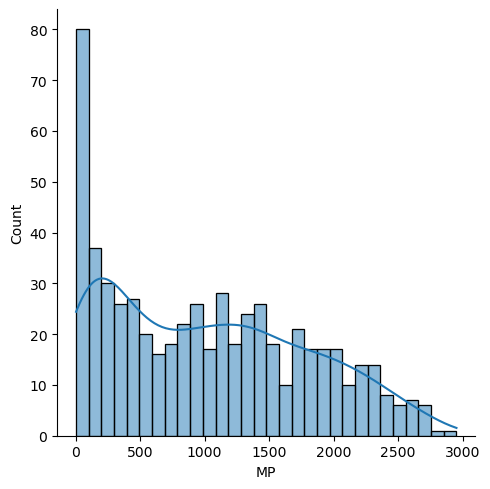

In [9]:
# Find the minute distribution of NBA Players

sns.displot(df['MP'], bins=30, kde=True)
plt.show()

Since there are 82 games in a single season, players without sufficient minutes would significantly affect the game results and the team standings. Even for players with good performance such as higher shooting accuracy and efficiency, the statistics would not be reliable, as the performance data was counted in non-critical minutes such as 'garbage time' in NBA games. The 'garbage time' of the game means the result has already been determined before the end of the game. The performance in that period is usually not critical since it does not significantly influence the final result. Injuries and changes in coaches' game plans are other reasons causing the players not to receive enough minutes to play.

In this regard, players with less than 1000 minutes in the season will be removed. 279 out of 582 players will be involved in the clustering analysis. It means the rest of the 192 players were eliminated from the final data set due to the insignificant playing time.

In [11]:
df_filtered = df[df['MP'] > 1000]
df_filtered.shape

(279, 57)

## Distribution of Player Traditional Positions

/var/folders/sg/m0jjhffs2_z8994hsfl5c5h00000gn/T/ipykernel_25238/3452442957.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pos_value_counts.index, y=pos_value_counts, palette='pastel')


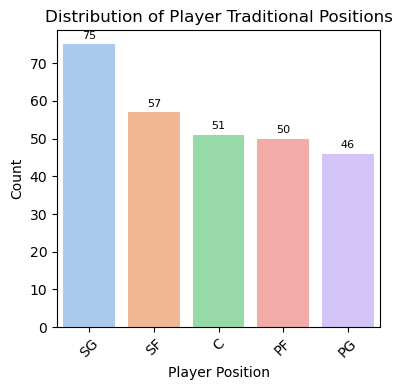

In [13]:
# Get the value counts of 'Pos' column
pos_value_counts = df_filtered['Pos'].value_counts()

# Create a bar plot using Seaborn
plt.figure(figsize=(4, 4))
sns.barplot(x=pos_value_counts.index, y=pos_value_counts, palette='pastel')
plt.title('Distribution of Player Traditional Positions', fontsize=12)
plt.xlabel('Player Position', fontsize=10)
plt.ylabel('Count', fontsize=10)

# Add labels to the bars
for i, count in enumerate(pos_value_counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', color='black', fontsize=8)

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

The numbers of SG are relatively higher while the numbers of PG are the lowest compared to other positions. 

## Visualizing Players By Traditional Positions

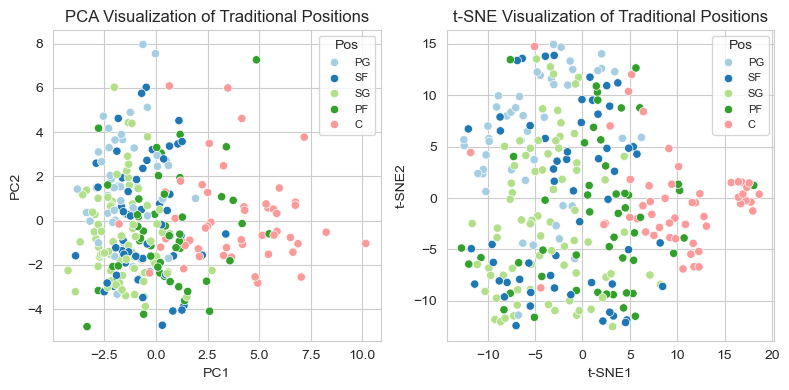

In [16]:
# Drop the unnecessary columns
x = df_filtered.copy()
x.drop(columns=['Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA',
               '2P', '2PA', 'eFG%', 'FT', 'ORB', 'DRB',
               'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF','Dist.', 'TS%', '3PAr',
               'OWS', 'DWS', 'WS', 'WS/48',
               'OBPM', 'DBPM', 'BPM', 'VORP'], axis=1, inplace=True)

# Data Normalization
scaler = StandardScaler()
x_std = scaler.fit_transform(x)

# Apply PCA on the original data
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(x_std)

# Apply t-SNE on the original data
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(x_std)

# Convert player positions (Pos) to numerical labels for color encoding
label_encoder = LabelEncoder()
Pos_encoded = label_encoder.fit_transform(df_filtered['Pos'])

# Convert numerical labels back to original string labels for legend
original_labels = label_encoder.inverse_transform(Pos_encoded)

# Create a DataFrame for visualization
pca_df = pd.DataFrame({'PC1': pca_result[:, 0], 'PC2': pca_result[:, 1], 'Pos': original_labels})
tsne_df = pd.DataFrame({'t-SNE1': tsne_result[:, 0], 't-SNE2': tsne_result[:, 1], 'Pos': original_labels})

# Create subplots with Seaborn
plt.figure(figsize=(8, 4))

# Set the style and background color
sns.set_style("whitegrid")
sns.set_palette("Paired")

plt.subplot(1, 2, 1)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Pos', palette='Paired')
plt.title('PCA Visualization of Traditional Positions')

# Adjust the legend font size
plt.legend(title='Pos', prop={'size': 8})

plt.subplot(1, 2, 2)
sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='Pos', palette='Paired')
plt.title('t-SNE Visualization of Traditional Positions')

# Adjust the legend font size
plt.legend(title='Pos', prop={'size': 8})

plt.tight_layout()
plt.show()

The above charts applied principal component analysis (PCA) t-Distributed Stochastic Neighbour Embedding (t-SNE) techniques to visualize players’ abilities in 2D charts. The data points in the charts are mostly overlapping and compressed, indicating no clear, separated groups are identified in both visualizations. As a result, poorly separated groups suggest that traditional positions cannot classify players explicitly. Despite the same position, different players may showcase diverse abilities. Evidently, It is beneficial to use ML-based clustering techniques to re-classify NBA players into new position groups based on their playing styles and tendencies, rather than traditional positions.

## Feature Selection

In [19]:
x = df_filtered.copy()
x.drop(columns=['Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA',
               '2P', '2PA', 'eFG%', 'FT', 'ORB', 'DRB',
               'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF','Dist.', 'TS%', '3PAr',
               'OWS', 'DWS', 'WS', 'WS/48',
               'OBPM', 'DBPM', 'BPM', 'VORP'], axis=1, inplace=True)
x.columns

Index(['3P%', '2P%', 'FTA', 'FT%', 'PTS', '% of FGA by 0-3 feet',
       '% of FGA by 3-10 feet', '% of FGA by 10-16 feet',
       '% of FGA by 16 feet - 3P', '% of FGA by 3P area', '% of 2PFG Ast'd',
       '% of 3P Ast'd', '%3PA Corner', 'PER', 'FTr', 'ORB%', 'DRB%', 'TRB%',
       'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%'],
      dtype='object')

## Data Standardization

In [21]:
scaler = StandardScaler()
x_std = scaler.fit_transform(x)
df_x_std = pd.DataFrame(x_std, columns=x.columns)
df_x_std.describe()

,3P%,2P%,FTA,FT%,PTS,% of FGA by 0-3 feet,% of FGA by 3-10 feet,% of FGA by 10-16 feet,% of FGA by 16 feet - 3P,% of FGA by 3P area,...,PER,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%
count,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,...,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02,2.790000e+02
mean,-8.595275e-17,6.366870e-18,-2.546748e-17,-5.220834e-16,-3.056098e-16,-1.910061e-16,-2.419411e-16,-7.640244e-17,-1.273374e-17,1.910061e-17,...,-4.074797e-16,-2.419411e-16,3.820122e-17,1.146037e-16,-3.565447e-16,-5.093496e-17,3.183435e-16,4.456809e-17,6.430539e-16,-3.056098e-16
std,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,...,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00,1.001797e+00
min,-3.222476e+00,-2.341623e+00,-1.594321e+00,-4.081039e+00,-1.863082e+00,-1.540115e+00,-2.270910e+00,-1.480839e+00,-1.023091e+00,-2.128898e+00,...,-1.912284e+00,-1.976304e+00,-1.202051e+00,-1.807395e+00,-1.701110e+00,-1.455267e+00,-1.861805e+00,-1.187060e+00,-2.287113e+00,-1.892506e+00
25%,-1.795108e-01,-6.197084e-01,-7.541505e-01,-5.333951e-01,-6.948798e-01,-6.965242e-01,-6.677347e-01,-7.808447e-01,-7.518925e-01,-5.421380e-01,...,-7.577661e-01,-7.213712e-01,-6.841325e-01,-7.494498e-01,-7.633778e-01,-7.599110e-01,-8.479269e-01,-7.225581e-01,-6.705566e-01,-7.322424e-01
50%,1.470282e-01,-8.161018e-02,-2.062130e-01,1.293515e-01,-1.430295e-01,-2.208153e-01,-1.258947e-01,-1.333501e-01,-2.920340e-01,7.250629e-02,...,-6.972000e-02,-1.525262e-01,-3.786932e-01,-2.294431e-01,-2.710684e-01,-2.925406e-01,-1.720080e-01,-2.580565e-01,-7.989184e-02,-1.431855e-01
75%,4.025806e-01,5.410463e-01,4.330474e-01,7.029893e-01,5.449917e-01,3.310070e-01,6.114544e-01,5.666440e-01,4.508143e-01,6.305724e-01,...,5.366935e-01,5.683002e-01,3.915448e-01,4.519450e-01,5.494471e-01,5.168081e-01,5.039108e-01,3.391599e-01,5.418605e-01,5.975981e-01
max,6.242424e+00,3.562083e+00,4.432991e+00,1.844696e+00,3.368745e+00,4.257191e+00,3.650227e+00,3.891616e+00,5.509258e+00,2.798544e+00,...,4.035233e+00,3.130274e+00,4.959853e+00,3.410604e+00,3.503303e+00,3.890994e+00,4.052485e+00,4.984176e+00,4.272375e+00,3.230504e+00


## Using PCA for dimensionality reduction

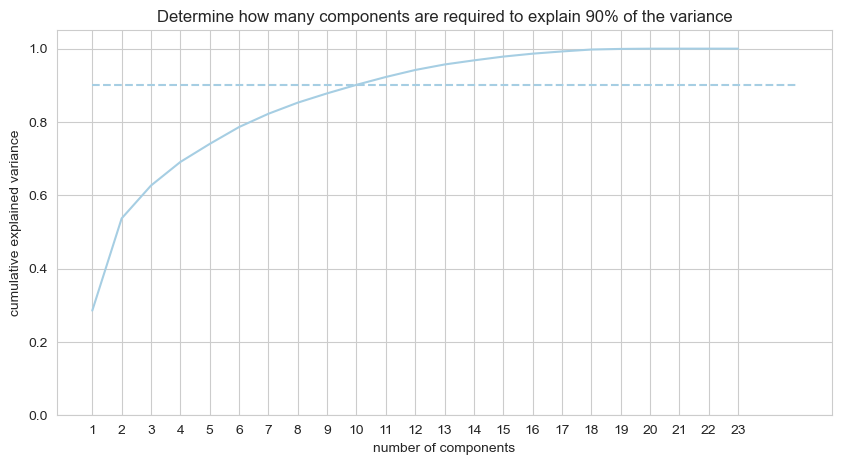

In [23]:
# Do a PCA transform

pca = PCA()
pca.fit(x_std)

# Determine how many components are required to explain 90% of the variance
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(np.cumsum(pca.explained_variance_ratio_))
ax.set_xlabel('number of components')
ax.set_ylabel('cumulative explained variance')
ax.set_title('Determine how many components are required to explain 90% of the variance')
ax.set_xticks(np.arange(0, 23), np.arange(1, 24))
ax.set_ylim([0,1.05])
ax.hlines(y=0.90, xmin=0, xmax=24, linestyles='--')
plt.show()

In [24]:
# Reduce our 23 dimensions down to 10 principal components as it can explain 90% of the variance
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_std)

# Convert the result back into a readable DataFrame
pca_df = pd.DataFrame(
    data=x_pca, 
    columns=[f'PC{i}' for i in range(1, 11)]
)
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,1.919624,1.005940,0.728089,1.628673,-1.025536,1.703196,0.378784,0.108034,-0.111731,-0.752682
1,-1.830037,4.625160,-1.020530,-1.244651,0.954072,1.901325,0.860252,-1.292558,0.609304,-0.196864
2,-1.293592,1.603760,-0.452178,-0.081538,-1.007630,0.325930,-0.301536,0.182357,0.382070,0.264355
3,-0.847375,-2.645676,0.093061,-0.333283,-0.039142,-1.048664,-0.460917,-0.191267,0.292075,-0.311013
4,-0.793304,-0.908077,-1.495730,-0.859855,0.950264,1.384136,0.041626,0.031460,-0.261045,-0.134668


## Dendrogram

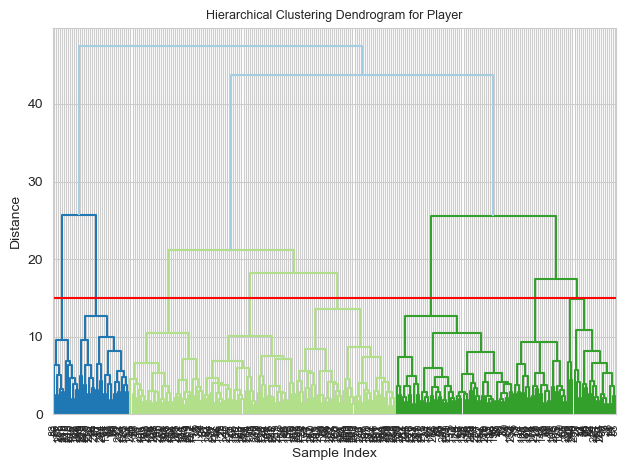

In [26]:
# Plot
plt.title('Hierarchical Clustering Dendrogram for Player',fontsize=9)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(linkage(x_pca, 'ward'))
plt.axhline(y = 15, color = 'r', linestyle = '-')

# Adjust tick label font size
plt.xticks(fontsize=8)


# Show the plots
plt.tight_layout()
plt.show()

Selection of the Optimal Cluster Count (K=8)
1. Statistical and Geometric Justification
After applying Principal Component Analysis (PCA) to capture 90% of the total variance, the underlying data noise was significantly reduced. When evaluating the resulting dendrogram generated via Ward’s Linkage (which minimizes within-cluster variance), a highly stable flat cutting plane emerges at a cophenetic distance threshold of approximately 15. Slicing the hierarchical tree at this specific height naturally yields 8 distinct intersections, representing the geometric configuration with the clearest cluster separation.
Standard partition-based metrics like the Elbow Method or Silhouette Score tend to fail on modern NBA datasets due to the continuous nature of the data space, often misleadingly oversimplifying the structure to K=2. The hierarchical dendrogram successfully bypasses this limitation.
2. Domain Knowledge and Tactical Interpretability
From a sports analytics perspective, K=8 offers a significantly higher and more refined level of granularity compared to the traditional, rigid five court positions (PG, SG, SF, PF, C), which are largely outdated in today's era of "Positionless Basketball." By computing the feature profiles via cluster centroids, these 8 groups map seamlessly onto contemporary tactical archetypes, such as:
Heliocentric Primary Playmakers (e.g., high-usage offensive engines)
Modern Unicorn Bigs (e.g., versatile, floor-spacing rim protectors)
3D Wings / Perimeter Lockdowns (e.g., low-usage defensive specialists)
Choosing a lower cluster count would result in severe underfitting—coarsely grouping fundamentally different players—while pushing beyond K>10 would trigger micro-clustering and overfitting. Such fragmentation splits highly similar archetypes into redundant subgroups, degrading the business interpretability of the model.
Therefore, K=8 stands as the most insightful, statistically robust, and managerially actionable solution for this project.

## Hierarchical Agglomerative Clustering (HAC)

In [29]:
agg_model = AgglomerativeClustering(n_clusters=8, linkage='ward')
y_agg = agg_model.fit_predict(x_pca)
df_x_std['Cluster_Label'] = y_agg
df_filtered['Cluster_Label'] = y_agg

/var/folders/sg/m0jjhffs2_z8994hsfl5c5h00000gn/T/ipykernel_25238/2367553754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Cluster_Label'] = y_agg


In [30]:
df_x_std.head()

,3P%,2P%,FTA,FT%,PTS,% of FGA by 0-3 feet,% of FGA by 3-10 feet,% of FGA by 10-16 feet,% of FGA by 16 feet - 3P,% of FGA by 3P area,...,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,Cluster_Label
0,-1.178058,0.318120,0.670487,0.051381,0.129312,0.838430,1.404663,0.479145,0.391858,-1.557973,...,0.985164,0.975863,-0.157718,0.338457,0.482610,0.503911,-0.258056,0.448598,-0.000384,7
1,0.686528,0.302746,1.254954,1.109548,1.734695,-1.178576,-0.695665,3.891616,2.655777,-0.446984,...,0.681201,-0.963012,-0.014268,-0.411728,0.516808,-1.016907,0.272803,0.448598,1.266981,0
2,0.478300,-0.266101,0.451312,1.488260,0.745665,-0.157387,0.488563,0.356646,0.509771,-0.308110,...,0.229599,-0.352133,-0.910831,-0.763378,0.357218,-0.340988,-0.457129,-0.390768,0.588673,1
3,0.279537,0.410365,-0.863738,-0.739459,-0.616044,-0.480869,-0.807384,-1.130842,-0.881596,1.286364,...,-0.925461,-0.059974,-0.570137,-0.388285,-0.657318,-0.172008,-0.523486,0.324247,-0.660842,6
4,0.213283,-0.235353,-0.315801,0.006827,-0.157363,-0.721895,-0.673321,1.231638,0.415441,0.447979,...,-0.395697,-0.192774,0.380220,0.174354,-1.010695,-1.185886,0.339160,-0.950345,-0.321688,5


In [31]:
df_filtered.head()

,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,3P,...,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Cluster_Label
Player,,,,,,,,,,,,,,,,,,,,,
Amen Thompson,23,HOU,PG,79,79,2953,9.4,17.7,0.534,0.4,...,20.0,6.5,3.8,10.3,0.167,1.6,1.0,2.6,3.4,7
Kevin Durant,37,HOU,SF,78,78,2840,12.6,24.2,0.520,3.3,...,27.1,7.5,3.2,10.7,0.180,4.4,0.1,4.5,4.7,0
Desmond Bane,27,ORL,SG,82,82,2756,10.2,21.0,0.484,2.9,...,23.3,4.8,2.6,7.4,0.129,1.6,-0.2,1.4,2.3,1
Toumani Camara,25,POR,PF,82,82,2731,6.9,15.6,0.440,3.8,...,16.3,2.1,2.7,4.8,0.084,-1.0,0.0,-1.0,0.7,6
Jabari Smith Jr.,22,HOU,PF,77,77,2705,8.1,18.0,0.450,3.3,...,18.2,3.4,3.3,6.6,0.118,-0.5,-0.2,-0.7,0.9,5


## Distinguishing Features of each Cluster

In [33]:
df_final = df_filtered.reset_index()

def characterize_clusters(df_final, cluster_column, mp_column='MP'):
    """
    List the notable players in each cluster and calculate the distinguishing Features between the cluster and the rest of the league
    """
    # Make sure players is set_index
    if 'Player' in df_final.columns:
        df_working = df_final.set_index('Player')
    else:
        df_working = df_final.copy()

    df_working.drop(columns=['Age', 'Team', 'Pos', 'G', 'GS', 'FG', 'FGA', 'FG%', '3P', '3PA',
               '2P', '2PA', 'eFG%', 'FT', 'ORB', 'DRB',
               'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF','Dist.', 'TS%', '3PAr',
               'OWS', 'DWS', 'WS', 'WS/48',
               'OBPM', 'DBPM', 'BPM', 'VORP'], axis=1, inplace=True)
        
    # Find all the independent clusters and sort (0, 1, 2...)
    unique_clusters = sorted(df_working[cluster_column].unique())
    
    for cluster in unique_clusters:
        cluster_data = df_working[df_working[cluster_column] == cluster]
        all_other = df_working[df_working[cluster_column] != cluster]
        
        print("\n" + "="*50)
        print(f"ANALYSIS FOR CLUSTER {cluster} (Total Players: {len(cluster_data)})")
        print("="*50)
        
        # 1. Find Notable Players (Top 10 by Minutes Played)
        print(" Notable Players (Top 10 by Minutes Played):")
        if mp_column in cluster_data.columns:
            top_players = cluster_data.nlargest(10, mp_column)
            # Player name is in idx, the stat is in row
            for idx, row in top_players.iterrows():
                print(f"  - {idx} (MP: {int(row[mp_column])})")
        else:
            sample_players = cluster_data.head(10)
            for idx, row in sample_players.iterrows():
                print(f"  - {idx}")
                
        # 2. Distinguishing Features
        print("\n Distinguishing Features (vs Rest of League):")
        
        # Compare the mean of all the numeric columns
        numeric_cols = cluster_data.select_dtypes(include=['number']).columns
        numeric_cols = [c for c in numeric_cols if c not in [cluster_column, 'ID', mp_column]]
        
        # Calculate the abs mean difference between the cluster and the rest of the league
        cluster_mean = cluster_data[numeric_cols].mean()
        other_mean = all_other[numeric_cols].mean()
        mean_diff = (cluster_mean - other_mean).abs()
        
        # Get the 20 largest difference
        top_20_highest_features = mean_diff.nlargest(20).index
        
        for feat in top_20_highest_features:
            diff_val = cluster_mean[feat] - other_mean[feat]
            if diff_val > 0:
                print(f"  - {feat}: HIGHER ⬆️ (Cluster Avg: {cluster_mean[feat]:.2f} vs Rest: {other_mean[feat]:.2f})")
            else:
                print(f"  - {feat}: LOWER ⬇️ (Cluster Avg: {cluster_mean[feat]:.2f} vs Rest: {other_mean[feat]:.2f})")

# Call the function
characterize_clusters(df_final, 'Cluster_Label', mp_column='MP')


ANALYSIS FOR CLUSTER 0 (Total Players: 24)
 Notable Players (Top 10 by Minutes Played):
  - Kevin Durant (MP: 2840)
  - Tyrese Maxey (MP: 2661)
  - Jamal Murray (MP: 2652)
  - Brandon Ingram (MP: 2604)
  - Jalen Brunson (MP: 2590)
  - Jaylen Brown (MP: 2443)
  - James Harden (MP: 2438)
  - DeMar DeRozan (MP: 2406)
  - Donovan Mitchell (MP: 2342)
  - Luka Dončić (MP: 2289)

 Distinguishing Features (vs Rest of League):
  - PTS: HIGHER ⬆️ (Cluster Avg: 37.86 vs Rest: 22.15)
  - AST%: HIGHER ⬆️ (Cluster Avg: 28.81 vs Rest: 14.98)
  - USG%: HIGHER ⬆️ (Cluster Avg: 30.80 vs Rest: 18.99)
  - PER: HIGHER ⬆️ (Cluster Avg: 23.01 vs Rest: 14.57)
  - FTA: HIGHER ⬆️ (Cluster Avg: 10.30 vs Rest: 4.24)
  - ORB%: LOWER ⬇️ (Cluster Avg: 3.26 vs Rest: 5.41)
  - DRB%: HIGHER ⬆️ (Cluster Avg: 16.18 vs Rest: 14.76)
  - TRB%: LOWER ⬇️ (Cluster Avg: 9.82 vs Rest: 10.08)
  - % of 2PFG Ast'd: LOWER ⬇️ (Cluster Avg: 0.37 vs Rest: 0.58)
  - % of 3P Ast'd: LOWER ⬇️ (Cluster Avg: 0.66 vs Rest: 0.85)
  - %3PA Cor

### Description of Clusters

Cluster 0: Primary playmakers and scorers, as they are superior on multiple statistics. Typically star players and team leaders of the team. High shot attempts and shots made indicate they have exceptional scoring abilities. High USG% indicates those players handle the ball extensively.  With low % of 2P FG Ast'd and % of 3P Ast'd, They tend to create their own shot opportunities. We call this position Ball Dominant Player.

##### Notable Player: Luka Dončić, Kevin Durant, James Harden, Jalen Brunson

Cluster 1: Those players are capable of scoring in multiple ways. Typically, the second or third scorers of the teams. Those players tended to make more shots in mid and long range. However, defense and rebounding are their weaknesses, as the statistics in other areas are below average. We call this position Secondary Playmakers.

##### Notable Player: Jaden McDaniels, Payton Pritchard, Desmond Bane, Derrick White

Cluster 2: Excel in the defensive side while most of the three-point shots were assisted and from the corner area. Higher than average STL indicates they were specialised in perimeter defence. We call this position 3-D Player.

##### Notable Player: OG Anunoby, Donte DiVincenzo, Royce O'Neale, Kris Dunn

Cluster 3: Centers or power forwards who typically play in the paint area. High shot attempts and percentage in close range or near the rim, proficient in rebounding and shot-blocking skills. They anchor the defence in the paint area, protect the rim, secure rebounds, and provide a physical presence in the paint on both offense and defensse. However, their shooting abilities are a weakness, and they seldom make shots out of the paint area of the court. We call this position Traditional Big Man.

##### Notable Player: Rudy Gobert, Jalen Duren, Deandre Ayton, Ivica Zubac

Cluster 4: Similar to Traditional Big Man on the defensive side but higher tendency on long-range shooting (% of 3P Ast'd and %3PA Corner). It helps create the spacing for the team’s offense and open up different scoring opportunities for the team. The versatile skills are more appropriate to modern basketball. We call this position Modern Two-Way Bigs.

##### Notable Player: Karl-Anthony Towns, Chet Holmgren, Evan Mobley, Donovan Clingan

Cluster 5: Those players exhibited higher-than-average performance on three-point shooting, including the quantities and accuracies. Also, they had significant higher tendency toward three-point shooting compared to other clusters. As a result, those players specialised in long-range shooting, indicating they can knock down the long-range shot consistently and providing spacing to the team. However, they were underperformed in other statistics. We call this position Pure Shooter.

##### Notable Player: Mikal Bridges, Duncan Robinson, Tim Hardaway Jr., A.J. Green

Cluster 6: It was typically the forward players with high ability to shoot from the long range. High attempts and shooting accuracy from the three-point line led to draw defenders out of the paint. Drawing defenders away from the basket helps create the spacing for the team’s offence and different scoring opportunities for the teammates. Also, they have above-average rebounding and rim protection abilities
We call this position Stretch Forward.

##### Notable Player: Myles Turner, Naz Reid, Josh Hart, Miles Bridges

Cluster 7: Possessing extremely high productivity and superstar-level playmaking ability (AST%: 23.84%, USG%: 24.42%). They are not adept at three-point shooting, but are extremely skilled at driving to the basket (high attempt percentages in 0-3 feet and 3-10 feet), drawing significant fouls. They don't rely on outside shooting, but rather on their powerful athleticism to penetrate the paint and score or create opportunities for teammates. We call this position Point Forward.

##### Notable Player: Scottie Barnes, Paolo Banchero, Julius Randle, Amen Thompson, Cooper Flagg

## Cluster Visualization

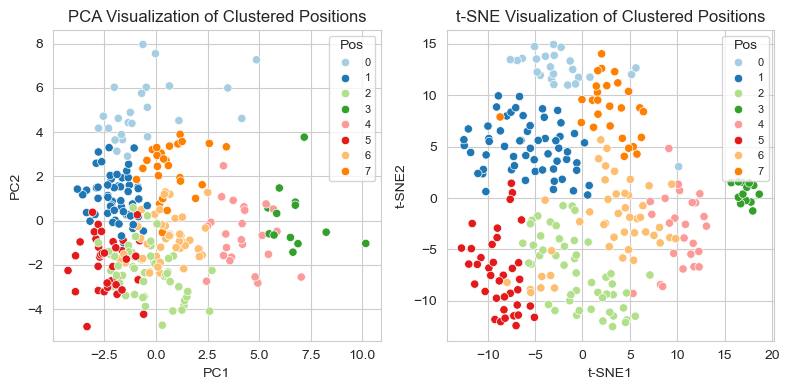

In [36]:
# Drop the unnecessary columns
x = df_filtered.copy()
x.drop(columns=['Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA',
               '2P', '2PA', 'eFG%', 'FT', 'ORB', 'DRB',
               'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF','Dist.', 'TS%', '3PAr',
               'OWS', 'DWS', 'WS', 'WS/48',
               'OBPM', 'DBPM', 'BPM', 'VORP', 'Cluster_Label'], axis=1, inplace=True)

# Data Normalization
scaler = StandardScaler()
x_std = scaler.fit_transform(x)

# Apply PCA on the original data
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(x_std)

# Apply t-SNE on the original data
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(x_std)

# Convert player positions (Pos) to numerical labels for color encoding
label_encoder = LabelEncoder()
Pos_encoded = label_encoder.fit_transform(df_filtered['Cluster_Label'])

# Convert numerical labels back to original string labels for legend
original_labels = label_encoder.inverse_transform(Pos_encoded)

# Create a DataFrame for visualization
pca_df = pd.DataFrame({'PC1': pca_result[:, 0], 'PC2': pca_result[:, 1], 'Cluster_Label': original_labels})
tsne_df = pd.DataFrame({'t-SNE1': tsne_result[:, 0], 't-SNE2': tsne_result[:, 1], 'Cluster_Label': original_labels})

# Create subplots with Seaborn
plt.figure(figsize=(8, 4))

# Set the style and background color
sns.set_style("whitegrid")
sns.set_palette("Paired")

plt.subplot(1, 2, 1)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster_Label', palette='Paired')
plt.title('PCA Visualization of Clustered Positions')

# Adjust the legend font size
plt.legend(title='Pos', prop={'size': 8})

plt.subplot(1, 2, 2)
sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='Cluster_Label', palette='Paired')
plt.title('t-SNE Visualization of Clustered Positions')

# Adjust the legend font size
plt.legend(title='Pos', prop={'size': 8})

plt.tight_layout()
plt.show()

The above diagrams display all clusters in scatter plots using PCA and t-SNE, respectively. Both algorithms did a decent job of visualising the clusters. The data points in the charts exhibited a higher degree of separation, indicating that more separated groups were identified after clustering. Evidently, using cluster techniques can effectively classify players in distinct positions. 
PCA is the linear method that exhibits the better global structure of the clusters, suggesting the overall relationship and patterns in the data across the dataset. t-SNE is the non-linear method, focusing on capturing the local relationships by revealing the similarities between the players. Some clusters in PCA were tightly grouped, while the separation of some clusters was still observable. Clusters in t-SNE were more distinct and well-separated than PCA.

## Distribution of Players Across the Clusters

In [39]:
# Create the custom labels mapping
custom_labels_f = {
    0: 'Ball Dominant Player',
    1: 'Secondary Playmakers',
    2: '3&D Wings',
    3: 'Traditional Big Man',
    4: 'Modern Two-Way Bigs',
    5: 'Pure Shooter',
    6: 'Stretch Forward',
    7: 'Point Forward'
}

# Apply the custom labels to the cluster labels
cluster_labels_name = [custom_labels_f[label] for label in y_agg]
df_final['cluster_labels_name'] = cluster_labels_name

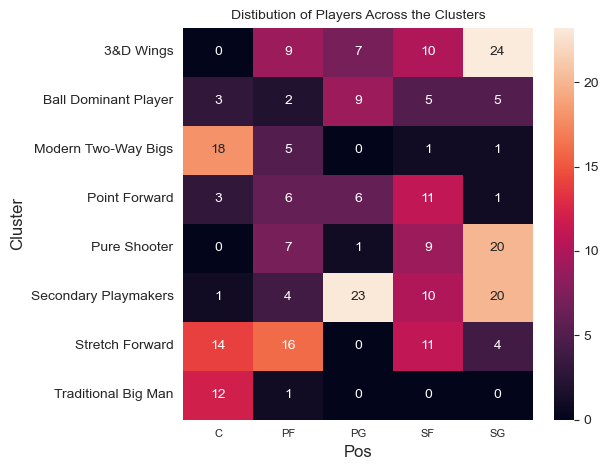

In [40]:
sns.heatmap(data=df_final.groupby(['cluster_labels_name', 'Pos']).size().unstack().fillna(0), annot=True, robust=True)
# Set the labels and title
plt.xlabel('Pos', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.title('Distibution of Players Across the Clusters', fontsize=10)

# Adjust tick label font size
plt.xticks(fontsize=8)

# Show the plots
plt.tight_layout()
plt.show()